<a href="https://colab.research.google.com/github/vishwa04vishu-eng/Medguardian.colab/blob/main/vishwas_joblib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df=pd.read_csv("/content/heart_data.csv")
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [ ]:
df.shape

(10000, 21)

In [ ]:
df.isnull().sum()

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


In [ ]:
df.drop(['Sleep Hours'],axis='columns',inplace=True)

In [ ]:
numerical_colummns=['Age'	,'Blood Pressure', 'Cholesterol Level', 'BMI',
                     'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level',
                     'Homocysteine Level']

for col in numerical_colummns:
  df[col].fillna(df[col].median(),inplace=True)

/tmp/ipython-input-2005453644.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [ ]:
categorical_columns = ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease',
                       'High Blood Pressure', 'Low HDL Cholesterol',
                       'High LDL Cholesterol', 'Alcohol Consumption',
                       'Stress Level', 'Sugar Consumption','Diabetes']

for col in categorical_columns:
  df[col].fillna(df[col].mode()[0],inplace=True)

/tmp/ipython-input-2226411169.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
lb=LabelEncoder()

In [ ]:
df['Gender']=lb.fit_transform(df['Gender'])
df['Exercise Habits']=lb.fit_transform(df['Exercise Habits'])
df['Smoking']=lb.fit_transform(df['Smoking'])
df['Family Heart Disease']=lb.fit_transform(df['Family Heart Disease'])
df['Diabetes']=lb.fit_transform(df['Diabetes'])
df['High Blood Pressure']=lb.fit_transform(df['High Blood Pressure'])
df['Low HDL Cholesterol']=lb.fit_transform(df['Low HDL Cholesterol'])
df['High LDL Cholesterol']=lb.fit_transform(df['High LDL Cholesterol'])
df['Alcohol Consumption']=lb.fit_transform(df['Alcohol Consumption'])
df['Stress Level']=lb.fit_transform(df['Stress Level'])
df['Sugar Consumption']=lb.fit_transform(df['Sugar Consumption'])
df['Heart Disease Status']=lb.fit_transform(df['Heart Disease Status'])

In [ ]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,1,153.0,155.0,0,1,1,0,24.991591,1,1,0,0,2,2,342.0,120.0,12.969246,12.387250,0
1,69.0,0,146.0,286.0,0,0,1,1,25.221799,0,1,0,2,0,2,133.0,157.0,9.355389,19.298875,0
2,46.0,1,126.0,216.0,1,0,0,0,29.855447,0,1,1,1,1,1,393.0,92.0,12.709873,11.230926,0
3,32.0,0,122.0,293.0,0,1,1,0,24.130477,1,0,1,1,0,0,293.0,94.0,12.509046,5.961958,0
4,60.0,1,166.0,242.0,1,1,1,1,20.486289,1,0,0,1,0,0,263.0,154.0,10.381259,8.153887,0


In [ ]:
df.tail()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
9995,25.0,0,136.0,243.0,2,1,0,0,18.788791,1,0,1,2,0,2,343.0,133.0,3.588814,19.132004,1
9996,38.0,1,172.0,154.0,2,0,0,0,31.856801,1,0,1,2,0,1,377.0,83.0,2.658267,9.715709,1
9997,73.0,1,152.0,201.0,0,1,0,1,26.899911,0,1,1,2,1,1,248.0,88.0,4.408867,9.492429,1
9998,23.0,1,142.0,299.0,1,1,0,1,34.964026,1,0,1,2,0,2,113.0,153.0,7.215634,11.873486,1
9999,38.0,0,128.0,193.0,2,1,1,1,25.111295,0,1,1,0,2,0,121.0,149.0,14.387810,6.208531,1


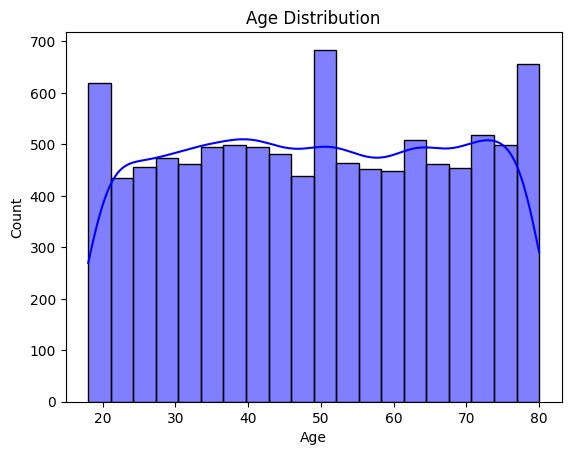

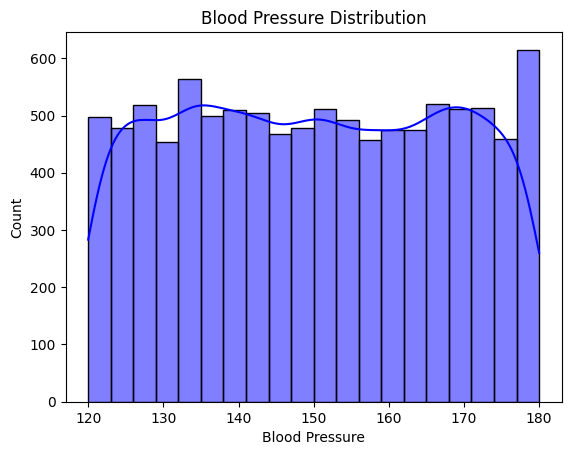

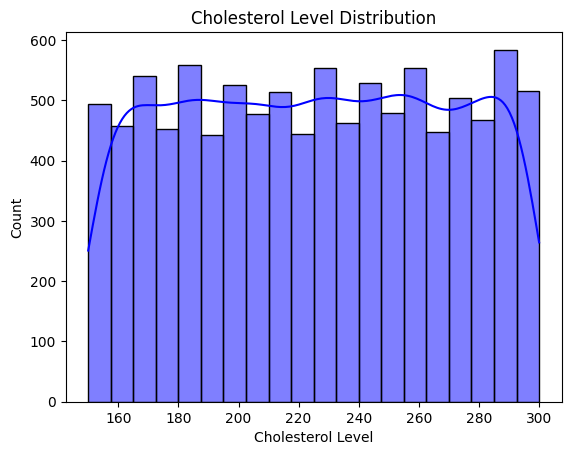

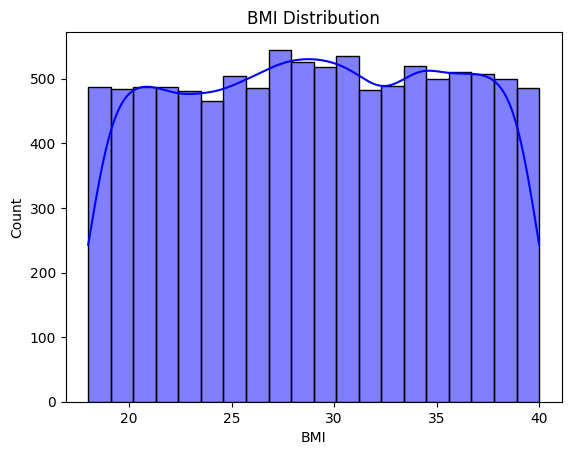

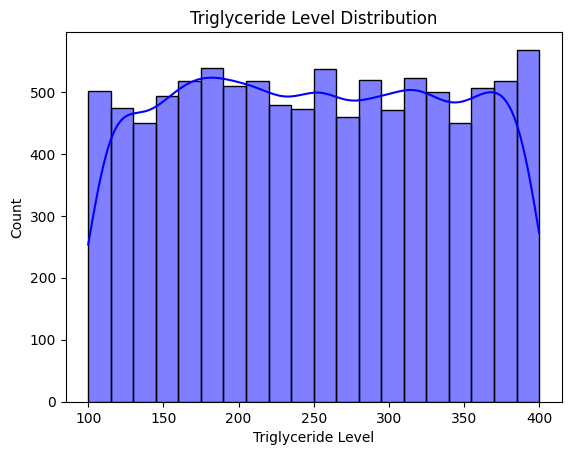

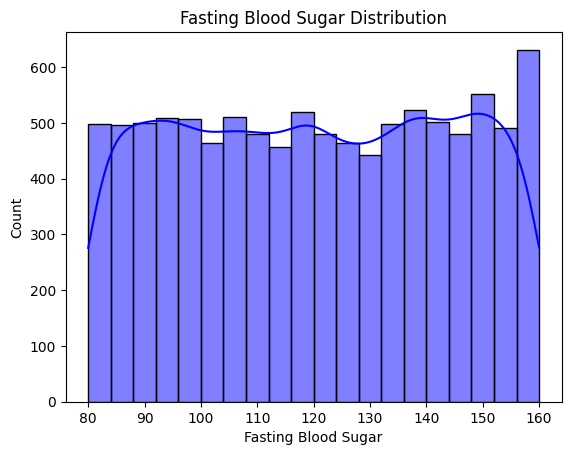

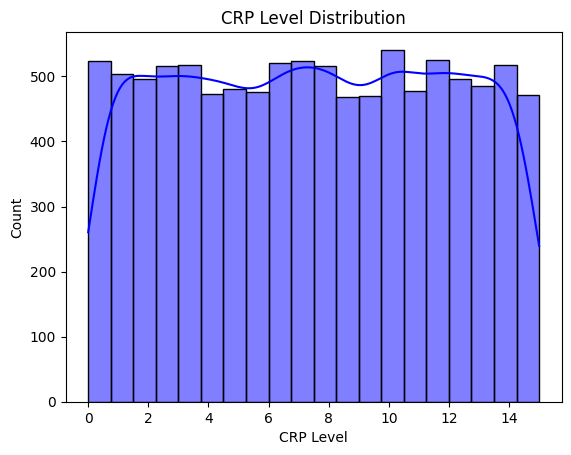

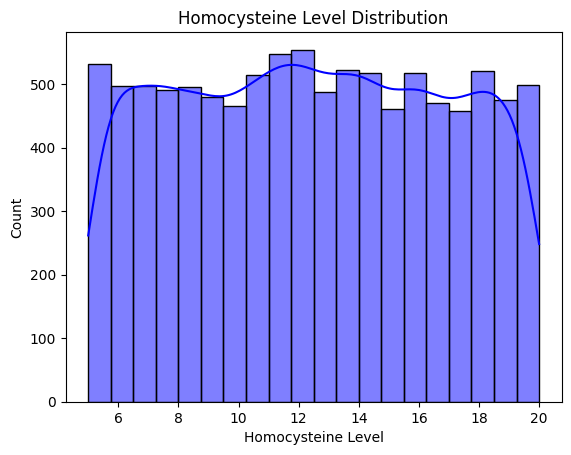

In [ ]:
columns1=['Age','Blood Pressure','Cholesterol Level','BMI','Triglyceride Level',
          'Fasting Blood Sugar','CRP Level','Homocysteine Level']
for i in columns1:
  sns.histplot(data=df[i],kde=True,color='blue',bins=20)
  plt.title(f'{i} Distribution')
  plt.show()

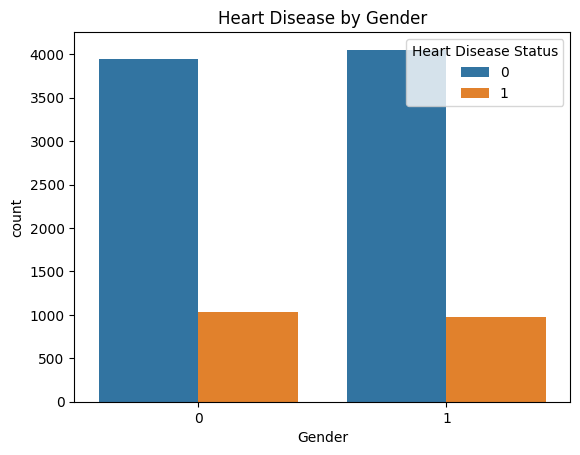

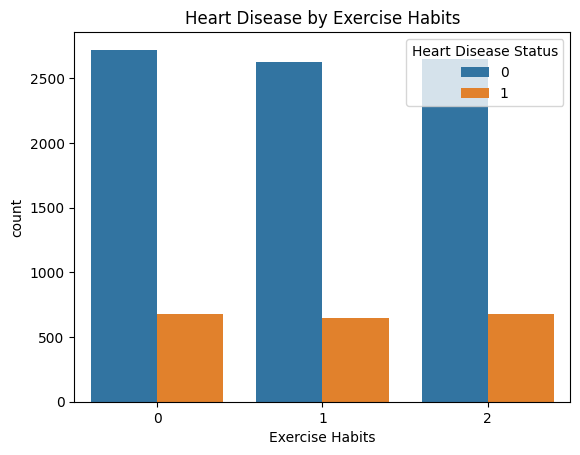

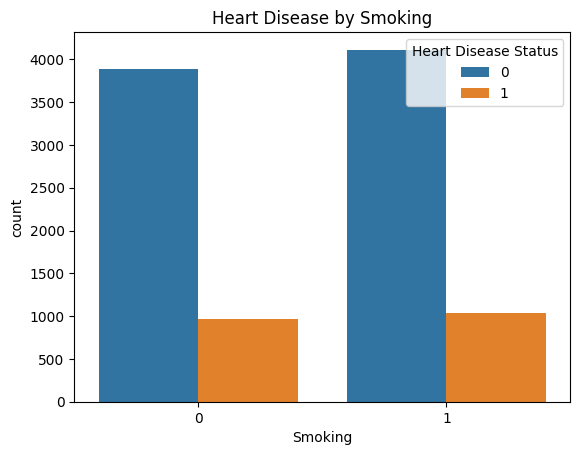

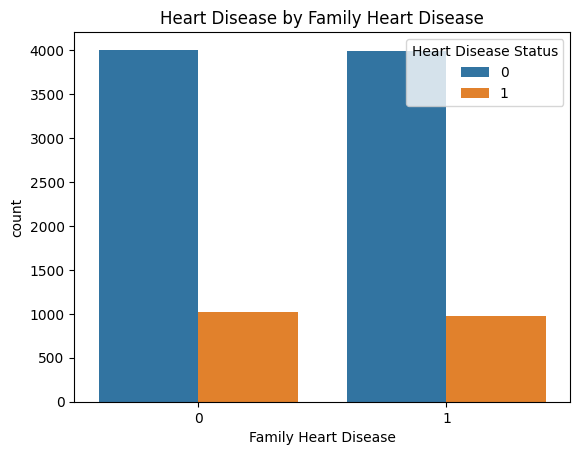

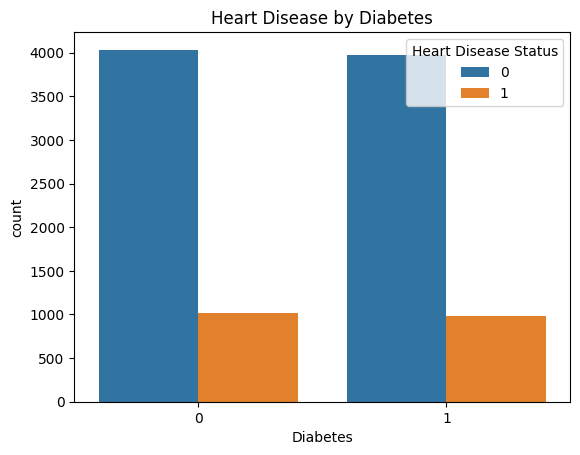

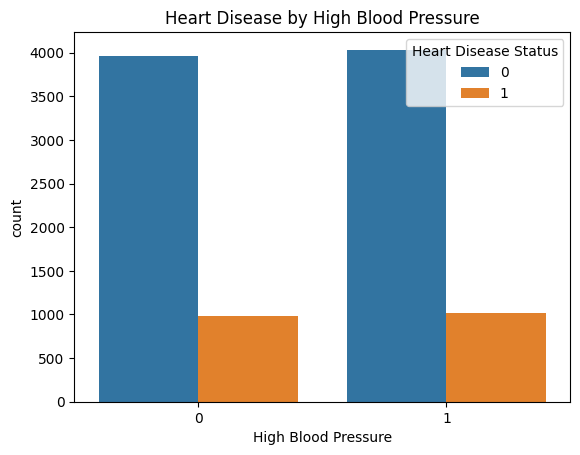

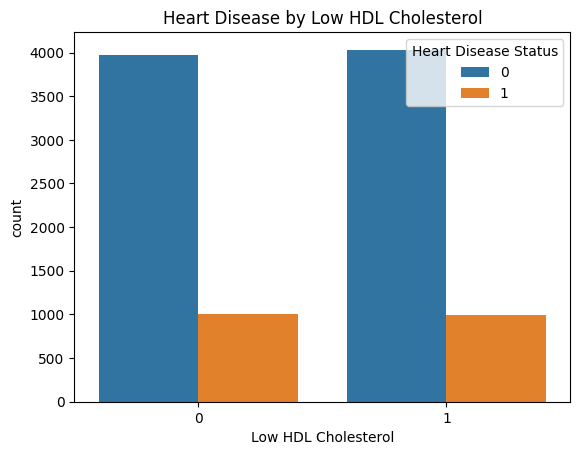

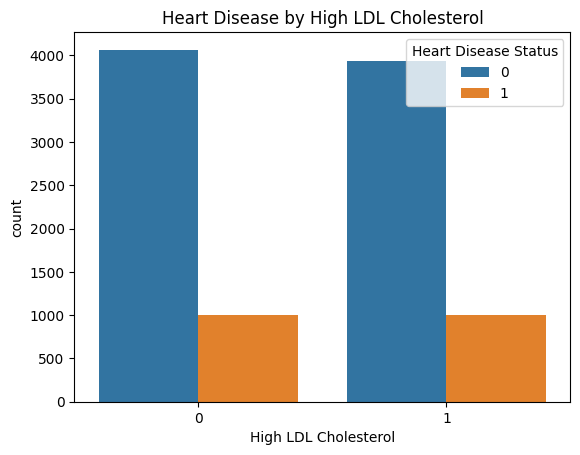

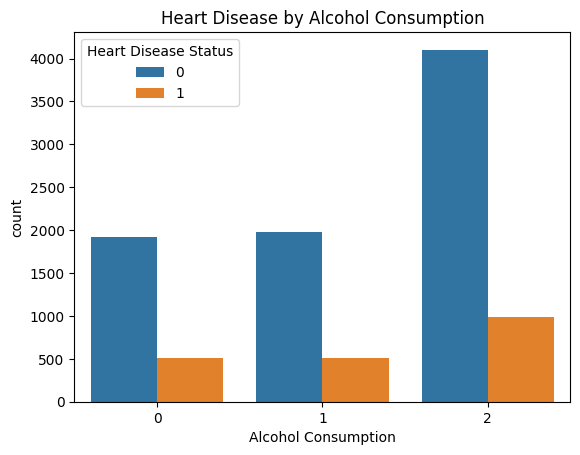

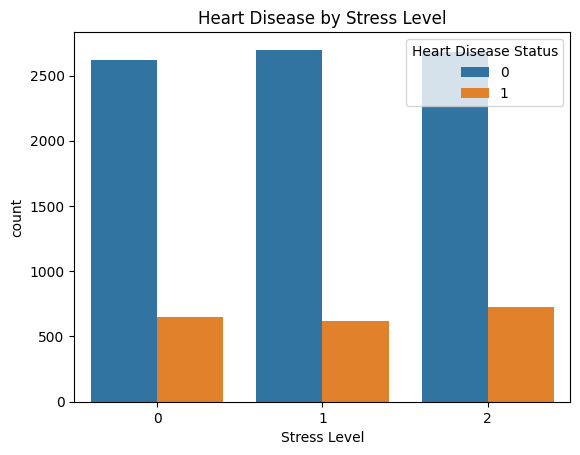

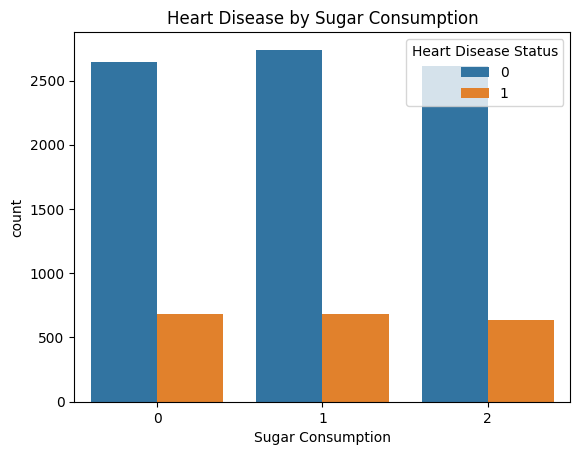

In [ ]:
columns=['Gender','Exercise Habits','Smoking','Family Heart Disease','Diabetes','High Blood Pressure','Low HDL Cholesterol',
         'High LDL Cholesterol','Alcohol Consumption','Stress Level','Sugar Consumption']
for i in columns:
  sns.countplot(data=df,x=i,hue='Heart Disease Status')
  plt.title(f'Heart Disease by {i}')
  plt.show()

In [ ]:
x=df.drop(['Heart Disease Status'],axis='columns')
y=df['Heart Disease Status']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print("x_train shape",x_train.shape)
print("x_test shape",x_test.shape)
print("y_train shape",y_train.shape)
print("y_test shape",y_test.shape)

x_train shape (8000, 19)
x_test shape (2000, 19)
y_train shape (8000,)
y_test shape (2000,)


In [ ]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred=lr.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Logistic Regression:",accuracy)

Logistic Regression: 0.8065


In [ ]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y_rfpred=rf.predict(x_test)
rf_accuracy=accuracy_score(y_test,y_pred)
print("Random Forest:",rf_accuracy)

Random Forest: 0.8065


In [ ]:
input_data = (69.0,0,146.0,286.0,0,0,1,1,25.221799,0,1,0,2,0,2,133.0,157.0,9.355389,19.298875	)
input_data_as_numpy_array= np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
prediction = rf.predict(input_data_reshaped)
print(prediction)
if (prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person have Heart Disease')

[0]
The Person does not have a Heart Disease


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Save the trained model
joblib.dump(rf, 'vishwas.joblib')

['vishwas.joblib']

In [ ]:
import joblib
model = joblib.load('vishwas.joblib')

In [ ]:
from google.colab import files
files.download('vishwas.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib

# Example: X_train, y_train = ...

# Create a pipeline that does scaling + model
pipeline = Pipeline([
    ("scaler", StandardScaler()),       # preprocessing
    ("model", RandomForestClassifier()) # your model
])

# Train the pipeline
pipeline.fit(x_train, y_train)

# Save the pipeline instead of just the model
joblib.dump(pipeline, "vishwas.joblib")

['vishwas.joblib']

In [ ]:
model = joblib.load("vishwas.joblib")


In [ ]:
from google.colab import files
files.download("vishwas.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>